---
title: "Лабораторна робота №3. Векторні моделі представлення тексту та подібність документів"
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
author: "&copy; Роменський В'ячеслав, 2026"
date: today
lang: uk
jupyter: python3

format:
  html:
    toc: true
    toc-location: right
    number-sections: false
    code-fold: true
    embed-resources: true
    self-contained-math: true
---


## Мета роботи

Опанувати базові векторні моделі представлення тексту: побудову моделі *Bag of Words*, матриці *документ–термін*, обчислення *TF-IDF* та оцінювання *подібності документів* за допомогою косинусної міри.


In [5]:
# Базові імпорти
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


## 1. Формування корпусу

Нижче наведено невеликий навчальний корпус українською мовою. Було додано до корпусу 20 текстів на тему текст майнінгу та машинного навчання.


In [3]:
base_corpus = [
    "Системи аналізу тексту використовують векторні моделі, статистичні ознаки та алгоритми машинного навчання.",
    "Попередня обробка текстових даних включає очищення, токенізацію та формування словника термінів.",
    "TF IDF зменшує вагу дуже частотних слів і підсилює інформативні терміни документа.",
    "Косинусна міра дозволяє порівнювати документи у просторі ознак та знаходити тематично близькі тексти.",
    "Рекомендаційні системи аналізують поведінкові дані користувачів і пропонують релевантний контент.",
    "Платформи соціальних медіа генерують великі обсяги текстових повідомлень для моніторингу та аналітики.",
    "Класифікація документів спирається на ознаки тексту та моделі машинного навчання.",
    "Аналітика даних допомагає виявляти закономірності у цифрових платформах та інформаційних потоках.",
    "Пошук подібних документів є важливим для інформаційного пошуку, кластеризації та рекомендацій.",
    "Модель мішка слів не враховує порядок слів, але є зручною базою для побудови матриці документ термін."
]

student_corpus = [
    "Текст майнінг використовується для автоматичного аналізу великих обсягів документів.",
    "Машинне навчання допомагає класифікувати тексти за темами та категоріями.",
    "Аналіз тональності дозволяє визначати позитивні або негативні відгуки клієнтів.",
    "Текст майнінг широко застосовується для виявлення ключових слів у статтях.",
    "Алгоритми машинного навчання можуть прогнозувати поведінку користувачів за текстовими даними.",
    "Обробка природної мови є важливою складовою сучасних систем аналізу тексту.",
    "Нейронні мережі використовуються для перекладу текстів між різними мовами.",
    "Текст майнінг допомагає компаніям вивчати думку споживачів у соціальних мережах.",
    "Моделі машинного навчання можуть автоматично виявляти спам у електронній пошті.",
    "Векторизація тексту перетворює слова у числові ознаки для аналізу.",
    "Тематичне моделювання дозволяє знаходити приховані теми у документах.",
    "Текст майнінг використовується у медицині для аналізу наукових публікацій.",
    "Рекомендаційні системи застосовують машинне навчання для персоналізації контенту.",
    "Автоматичне резюмування текстів допомагає швидко отримувати головну інформацію.",
    "Машинне навчання використовується для розпізнавання шахрайських повідомлень.",
    "Текст майнінг дозволяє аналізувати новини та виявляти інформаційні тренди.",
    "Глибоке навчання покращує якість розпізнавання змісту складних текстів.",
    "Чат-боти використовують обробку мови для спілкування з користувачами.",
    "Аналіз частоти слів допомагає знаходити найважливіші поняття у текстах.",
    "Поєднання текст майнінгу та машинного навчання відкриває нові можливості для бізнесу."
]

corpus = base_corpus + student_corpus
print(f"Загальна кількість документів у корпусі: {len(corpus)}")


Загальна кількість документів у корпусі: 30


## 2. Очищення тексту

Для створення однорідного тексту було виконано очищення тексту, що включає зведення тексту до нижнього регістру, заміни схожих символів на один єдиний варіант (наприклад, апостроф), прибирання спеціальних символів, цифр, підкреслень, дефісів, слешів та зайвих пробілів.

In [8]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'")
    text = re.sub(r"[-_/]", " ", text)
    text = re.sub(r"[^\w\sіїєґІЇЄҐ']", " ", text, flags=re.UNICODE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_corpus = [clean_text(text) for text in corpus]

clean_corpus[-5:]


['текст майнінг дозволяє аналізувати новини та виявляти інформаційні тренди',
 'глибоке навчання покращує якість розпізнавання змісту складних текстів',
 'чат боти використовують обробку мови для спілкування з користувачами',
 'аналіз частоти слів допомагає знаходити найважливіші поняття у текстах',
 'поєднання текст майнінгу та машинного навчання відкриває нові можливості для бізнесу']

## 3. Токенізація та базова фільтрація, стемінг

Було проведено три єтапи: токенізація, очищення від стоп-слів та стемінг. 
Буде перевірено два варіанти корпусів:
- тільки токенізований;
- токенізований, очищений та із прибраними закінченнями.


In [9]:
def tokenize(text: str) -> list[str]:
    return [token for token in text.split() if len(token) >= 2]

tokenized_corpus = [tokenize(text) for text in clean_corpus]

tokenized_corpus[-1]


['поєднання',
 'текст',
 'майнінгу',
 'та',
 'машинного',
 'навчання',
 'відкриває',
 'нові',
 'можливості',
 'для',
 'бізнесу']

### Видалення частини стоп-слів

Для частотного аналізу корисно порівнювати результати *зі стоп-словами* і *без стоп-слів*.  
Нижче наведено компактний список поширених українських службових слів.


In [11]:
uk_stopwords = {
    "і", "й", "та", "а", "але", "або", "що", "це", "у", "в", "до", "на", "за",
    "із", "з", "як", "для", "не", "по", "про", "при", "від", "над", "під",
    "то", "же", "чи", "його", "її", "їх", "бути",
    "між", "тому", "тоді", "ж"
}

filtered_corpus = [
    [token for token in doc if token not in uk_stopwords]
    for doc in tokenized_corpus
]

filtered_corpus[:3]


[['системи',
  'аналізу',
  'тексту',
  'використовують',
  'векторні',
  'моделі',
  'статистичні',
  'ознаки',
  'алгоритми',
  'машинного',
  'навчання'],
 ['попередня',
  'обробка',
  'текстових',
  'даних',
  'включає',
  'очищення',
  'токенізацію',
  'формування',
  'словника',
  'термінів'],
 ['tf',
  'idf',
  'зменшує',
  'вагу',
  'дуже',
  'частотних',
  'слів',
  'підсилює',
  'інформативні',
  'терміни',
  'документа']]

### Стемінг
Далі було створено просту функцію для видалення закінчень, аби звести слова до їх основ. Цей крок був доданий для того, аби знайти більш точні дані щодо частоти появи різних слів.

In [26]:
def simple_stem(word):
    suffixes = ["ують","ого","ими","ами","ями","ів","ий","ою","ів","ів","их","ує","яє","о","а","у","і","е","и"]
    for suf in suffixes:
        if word.endswith(suf):
            return word[:-len(suf)]
    return word

stemmed_corpus = [
    [simple_stem(token) for token in doc]
    for doc in filtered_corpus
]

stemmed_corpus[-3:]

[['чат', 'бот', 'використов', 'обробк', 'мов', 'спілкування', 'користувач'],
 ['аналіз',
  'частот',
  'сл',
  'допомагає',
  'знаходит',
  'найважливіш',
  'поняття',
  'текстах'],
 ['поєднання',
  'текст',
  'майнінг',
  'машинн',
  'навчання',
  'відкриває',
  'нов',
  'можливост',
  'бізнес']]

## 4. Формування фінального корпусу для векторизації

Щоб передати тексти у векторизатори `scikit-learn`, зберемо токени назад у рядки. Створимо датафрейм і для текстів після фільтрації, і для текстів без фільтрації.


In [30]:
analysis_texts_1 = [" ".join(doc) for doc in tokenized_corpus]

analysis_df_1 = pd.DataFrame({
    "doc_id": [f"D{i}" for i in range(1, len(analysis_texts_1) + 1)],
    "text": analysis_texts_1
})


analysis_texts_2 = [" ".join(doc) for doc in stemmed_corpus]

analysis_df_2 = pd.DataFrame({
    "doc_id": [f"D{i}" for i in range(1, len(analysis_texts_2) + 1)],
    "text": analysis_texts_2
})


print("Корпус 1:")
display(analysis_df_1.head())

print("Корпус 2:")
display(analysis_df_2.head())


Корпус 1:


,doc_id,text
0,D1,системи аналізу тексту використовують векторні...
1,D2,попередня обробка текстових даних включає очищ...
2,D3,tf idf зменшує вагу дуже частотних слів підсил...
3,D4,косинусна міра дозволяє порівнювати документи ...
4,D5,рекомендаційні системи аналізують поведінкові ...


Корпус 2:


,doc_id,text
0,D1,систем аналіз текст використов векторн модел с...
1,D2,попередня обробк текстов дан включає очищення ...
2,D3,tf idf зменш ваг дуж частотн сл підсилює інфор...
3,D4,косинусн мір дозвол порівнюват документ просто...
4,D5,рекомендаційн систем аналіз поведінков дан кор...


## 5. Побудова моделі Bag of Words

Модель *Bag of Words* описує кожен документ через **кількість входжень термінів** зі словника корпусу.  
Для цього побудуємо векторизатор `CountVectorizer`, який автоматично:

1. сформує словник;
2. поставить у відповідність кожному терміну індекс;
3. побудує матрицю **документ–термін**.

У цій матриці:

- рядки — документи;
- стовпці — терміни;
- значення — кількість входжень терміна в документ.


In [36]:
count_vectorizer = CountVectorizer()
X_count_1 = count_vectorizer.fit_transform(analysis_texts_1)

vocabulary_1 = count_vectorizer.get_feature_names_out()

print("Корпус 1:")
print(f"Кількість документів: {X_count_1.shape[0]}")
print(f"Розмір словника: {X_count_1.shape[1]}")
print("Перші 20 термінів словника:")
print(vocabulary_1[:20])

print()

X_count_2 = count_vectorizer.fit_transform(analysis_texts_2)

vocabulary_2 = count_vectorizer.get_feature_names_out()

print("Корпус 2:")
print(f"Кількість документів: {X_count_2.shape[0]}")
print(f"Розмір словника: {X_count_2.shape[1]}")
print("Перші 20 термінів словника:")
print(vocabulary_2[:20])


Корпус 1:
Кількість документів: 30
Розмір словника: 192
Перші 20 термінів словника:
['idf' 'tf' 'або' 'автоматичне' 'автоматично' 'автоматичного' 'алгоритми'
 'але' 'аналіз' 'аналізу' 'аналізувати' 'аналізують' 'аналітика'
 'аналітики' 'базою' 'близькі' 'боти' 'бізнесу' 'вагу' 'важливим']

Корпус 2:
Кількість документів: 30
Розмір словника: 153
Перші 20 термінів словника:
['idf' 'tf' 'автоматичн' 'алгоритм' 'аналіз' 'аналізуват' 'аналітик' 'баз'
 'близьк' 'бот' 'бізнес' 'ваг' 'важлив' 'важливим' 'векторизація'
 'векторн' 'велик' 'вивчат' 'визначат' 'використов']


## 6. Матриця «документ–термін»

Для зручності перетворимо матрицю ознак у табличний формат `pandas`.  
Оскільки реальна матриця може бути дуже широкою, нижче виведемо лише фрагмент.


In [42]:
dtm_count_df_1 = pd.DataFrame(
    X_count_1.toarray(),
    index=analysis_df_1["doc_id"],
    columns=vocabulary_1
)

print("Фрагмент матриці 'документ–термін' (Bag of Words):")
display(dtm_count_df_1.iloc[:10, :15])

dtm_count_df_2 = pd.DataFrame(
    X_count_2.toarray(),
    index=analysis_df_2["doc_id"],
    columns=vocabulary_2
)

print("Фрагмент матриці 'документ–термін' (Bag of Words):")
display(dtm_count_df_2.iloc[:10, :15])

Фрагмент матриці 'документ–термін' (Bag of Words):


,idf,tf,або,автоматичне,автоматично,автоматичного,алгоритми,але,аналіз,аналізу,аналізувати,аналізують,аналітика,аналітики,базою
doc_id,,,,,,,,,,,,,,,
D1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
D2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
D4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D5,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
D6,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
D7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
D9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Фрагмент матриці 'документ–термін' (Bag of Words):


,idf,tf,автоматичн,алгоритм,аналіз,аналізуват,аналітик,баз,близьк,бот,бізнес,ваг,важлив,важливим,векторизація
doc_id,,,,,,,,,,,,,,,
D1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
D2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D3,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0
D4,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
D5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
D6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
D7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
D9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 7. Найчастотніші терміни в моделі Bag of Words

Хоча ця лабораторна робота присвячена не частотному аналізу як такому, корисно побачити,  
які саме терміни формують основу словника векторайзера.


In [41]:
term_frequencies_1 = np.asarray(X_count_1.sum(axis=0)).ravel()

bow_freq_df_1 = pd.DataFrame({
    "term": vocabulary_1,
    "count": term_frequencies_1
}).sort_values("count", ascending=False).reset_index(drop=True)

term_frequencies_2 = np.asarray(X_count_2.sum(axis=0)).ravel()

bow_freq_df_2 = pd.DataFrame({
    "term": vocabulary_2,
    "count": term_frequencies_2
}).sort_values("count", ascending=False).reset_index(drop=True)

print("Корпус 1:")
display(bow_freq_df_1.head(10))
print("Корпус 2:")
display(bow_freq_df_2.head(10))


Корпус 1:


,term,count
0,для,12
1,та,10
2,навчання,9
3,текст,6
4,машинного,5
5,аналізу,5
6,допомагає,5
7,майнінг,5
8,слів,5
9,тексту,4


Корпус 2:


,term,count
0,текст,15
1,навчання,9
2,машинн,8
3,аналіз,8
4,документ,6
5,майнінг,6
6,допомагає,5
7,сл,5
8,ознак,4
9,систем,4


### 8. Створення матриці TF

In [50]:
doc_lengths_1 = X_count_1.toarray().sum(axis=1, keepdims=True)
doc_lengths_1[doc_lengths_1 == 0] = 1  # захист від ділення на нуль

tf_matrix_1 = X_count_1.toarray() / doc_lengths_1
tf_df_1 = pd.DataFrame(tf_matrix_1, index=analysis_df_1["doc_id"], columns=vocabulary_1)

doc_lengths_2 = X_count_2.toarray().sum(axis=1, keepdims=True)
doc_lengths_2[doc_lengths_2 == 0] = 1  # захист від ділення на нуль

tf_matrix_2 = X_count_2.toarray() / doc_lengths_2
tf_df_2 = pd.DataFrame(tf_matrix_2, index=analysis_df_2["doc_id"], columns=vocabulary_2)

print("Фрагмент матриці TF:")
display(tf_df_1.iloc[:5, :15].round(3))

print("Фрагмент матриці TF:")
display(tf_df_2.iloc[:5, :15].round(3))

Фрагмент матриці TF:


,idf,tf,або,автоматичне,автоматично,автоматичного,алгоритми,але,аналіз,аналізу,аналізувати,аналізують,аналітика,аналітики,базою
doc_id,,,,,,,,,,,,,,,
D1,0.000,0.000,0.0,0.0,0.0,0.0,0.083,0.0,0.0,0.083,0.0,0.000,0.0,0.0,0.0
D2,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0
D3,0.091,0.091,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0
D4,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0
D5,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.111,0.0,0.0,0.0


Фрагмент матриці TF:


,idf,tf,автоматичн,алгоритм,аналіз,аналізуват,аналітик,баз,близьк,бот,бізнес,ваг,важлив,важливим,векторизація
doc_id,,,,,,,,,,,,,,,
D1,0.000,0.000,0.0,0.091,0.091,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0
D2,0.000,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0
D3,0.091,0.091,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.091,0.0,0.0,0.0
D4,0.000,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.091,0.0,0.0,0.000,0.0,0.0,0.0
D5,0.000,0.000,0.0,0.000,0.111,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0


### 9. Порівняння частки нулів

In [51]:
def calculate_sparsity(df):
    total_elements = df.size
    zero_elements = (df == 0).sum().sum()
    sparsity = zero_elements / total_elements
    return sparsity, zero_elements, total_elements

sparsity_1, zeros_1, total_1 = calculate_sparsity(tf_df_1)
sparsity_2, zeros_2, total_2 = calculate_sparsity(tf_df_2)

comparison_df = pd.DataFrame({
    "Параметр": ["Кількість нулів", "Загальна кількість елементів", "Частка нулів (Sparsity)"],
    "Матриця 1": [zeros_1, total_1, f"{sparsity_1:.2%}"],
    "Матриця 2": [zeros_2, total_2, f"{sparsity_2:.2%}"]
})

display(comparison_df)

,Параметр,Матриця 1,Матриця 2
0,Кількість нулів,5477,4337
1,Загальна кількість елементів,5760,4590
2,Частка нулів (Sparsity),95.09%,94.49%


## 10. Побудова TF-IDF-подання корпусу

Тепер скористаємося `TfidfVectorizer`, який автоматично формує матрицю TF-IDF.  
На відміну від простої BoW-моделі, тут ваги відображають не лише локальну частоту, а й *інформативність терміна відносно всього корпусу*.


In [54]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf_1 = tfidf_vectorizer.fit_transform(analysis_texts_1)

tfidf_terms_1 = tfidf_vectorizer.get_feature_names_out()

tfidf_df_1 = pd.DataFrame(
    X_tfidf_1.toarray(),
    index=analysis_df_1["doc_id"],
    columns=tfidf_terms_1
)

X_tfidf_2 = tfidf_vectorizer.fit_transform(analysis_texts_2)

tfidf_terms_2 = tfidf_vectorizer.get_feature_names_out()

tfidf_df_2 = pd.DataFrame(
    X_tfidf_2.toarray(),
    index=analysis_df_2["doc_id"],
    columns=tfidf_terms_2
)

print("Фрагмент матриці TF-IDF 1:")
display(tfidf_df_1.iloc[:5, :15].round(3))

print("Фрагмент матриці TF-IDF 2:")
display(tfidf_df_2.iloc[:5, :15].round(3))


Фрагмент матриці TF-IDF 1:


,idf,tf,або,автоматичне,автоматично,автоматичного,алгоритми,але,аналіз,аналізу,аналізувати,аналізують,аналітика,аналітики,базою
doc_id,,,,,,,,,,,,,,,
D1,0.000,0.000,0.0,0.0,0.0,0.0,0.32,0.0,0.0,0.253,0.0,0.000,0.0,0.0,0.0
D2,0.000,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0
D3,0.308,0.308,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0
D4,0.000,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0
D5,0.000,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.348,0.0,0.0,0.0


Фрагмент матриці TF-IDF 2:


,idf,tf,автоматичн,алгоритм,аналіз,аналізуват,аналітик,баз,близьк,бот,бізнес,ваг,важлив,важливим,векторизація
doc_id,,,,,,,,,,,,,,,
D1,0.000,0.000,0.0,0.346,0.232,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0
D2,0.000,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0
D3,0.321,0.321,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.321,0.0,0.0,0.0
D4,0.000,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.348,0.0,0.0,0.000,0.0,0.0,0.0
D5,0.000,0.000,0.0,0.000,0.230,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0


## 11. Найважливіші терміни для окремих документів


In [57]:
def top_terms_for_document(tfidf_table: pd.DataFrame, doc_id: str, top_k: int = 8) -> pd.DataFrame:
    row = tfidf_table.loc[doc_id]
    result = (
        pd.DataFrame({"term": row.index, "tfidf": row.values})
        .query("tfidf > 0")
        .sort_values("tfidf", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )
    return result

print("Корпус 1:")
for doc_id in tfidf_df_1.index[:3]:
    print(f"\nНайважливіші терміни для {doc_id}:")
    display(top_terms_for_document(tfidf_df_1, doc_id, top_k=8).round(3))

    
print("Корпус 2:")
for doc_id in tfidf_df_2.index[:3]:
    print(f"\nНайважливіші терміни для {doc_id}:")
    display(top_terms_for_document(tfidf_df_2, doc_id, top_k=8).round(3))


Корпус 1:

Найважливіші терміни для D1:


,term,tfidf
0,векторні,0.359
1,статистичні,0.359
2,використовують,0.320
3,алгоритми,0.320
4,системи,0.292
5,моделі,0.292
6,ознаки,0.292
7,тексту,0.271



Найважливіші терміни для D2:


,term,tfidf
0,включає,0.321
1,попередня,0.321
2,очищення,0.321
3,формування,0.321
4,токенізацію,0.321
5,словника,0.321
6,термінів,0.321
7,обробка,0.287



Найважливіші терміни для D3:


...

,term,tfidf
0,векторн,0.388
1,статистичн,0.388
2,алгоритм,0.346
3,використов,0.346
4,модел,0.316
5,систем,0.293
6,ознак,0.293
7,аналіз,0.232



Найважливіші терміни для D2:


,term,tfidf
0,включає,0.342
1,очищення,0.342
2,токенізацію,0.342
3,попередня,0.342
4,словник,0.342
5,формування,0.342
6,термін,0.278
7,обробк,0.278



Найважливіші терміни для D3:


,term,tfidf
0,idf,0.321
1,tf,0.321
2,ваг,0.321
3,дуж,0.321
4,зменш,0.321
5,підсилює,0.321
6,інформативн,0.321
7,частотн,0.321


## 12. Порівняння BoW і TF-IDF на прикладі одного документа

Подивимось, як змінюється представлення документа:

- у *BoW* домінують терміни за кількістю входжень;
- у *TF-IDF* більшу вагу отримують терміни, що краще відрізняють документ від інших.

Це наочно демонструє різницю між *простим підрахунком* і *зваженим представленням*.


In [61]:
example_doc_id_1 = analysis_df_1["doc_id"].iloc[0]

bow_row_1 = dtm_count_df_1.loc[example_doc_id]
tfidf_row_1 = tfidf_df_1.loc[example_doc_id]

comparison_df_1 = pd.DataFrame({
    "term": dtm_count_df_1.columns,
    "bow_count": bow_row_1.values,
    "tfidf_weight": tfidf_row_1.reindex(dtm_count_df_1.columns).values
})

comparison_df_1 = (
    comparison_df_1
    .query("bow_count > 0")
    .sort_values(["tfidf_weight", "bow_count"], ascending=False)
    .reset_index(drop=True)
)

example_doc_id_2 = analysis_df_2["doc_id"].iloc[0]

bow_row_2 = dtm_count_df_2.loc[example_doc_id]
tfidf_row_2 = tfidf_df_2.loc[example_doc_id]

comparison_df_2 = pd.DataFrame({
    "term": dtm_count_df_2.columns,
    "bow_count": bow_row_2.values,
    "tfidf_weight": tfidf_row_2.reindex(dtm_count_df_2.columns).values
})

comparison_df_2 = (
    comparison_df_2
    .query("bow_count > 0")
    .sort_values(["tfidf_weight", "bow_count"], ascending=False)
    .reset_index(drop=True)
)

display(comparison_df_1.head(15).round(3))
display(comparison_df_2.head(15).round(3))


,term,bow_count,tfidf_weight
0,векторні,1,0.359
1,статистичні,1,0.359
2,алгоритми,1,0.320
3,використовують,1,0.320
4,моделі,1,0.292
5,ознаки,1,0.292
6,системи,1,0.292
7,тексту,1,0.271
8,аналізу,1,0.253
9,машинного,1,0.253


,term,bow_count,tfidf_weight
0,векторн,1,0.388
1,статистичн,1,0.388
2,алгоритм,1,0.346
3,використов,1,0.346
4,модел,1,0.316
5,ознак,1,0.293
6,систем,1,0.293
7,аналіз,1,0.232
8,машинн,1,0.232
9,навчання,1,0.221


## 13. Косинусна подібність документів у просторі TF-IDF

Далі виконаємо те саме для TF-IDF-подання.  
Зазвичай саме такий варіант краще відображає *змістову близькість* документів, оскільки зменшує вплив загальних слів.


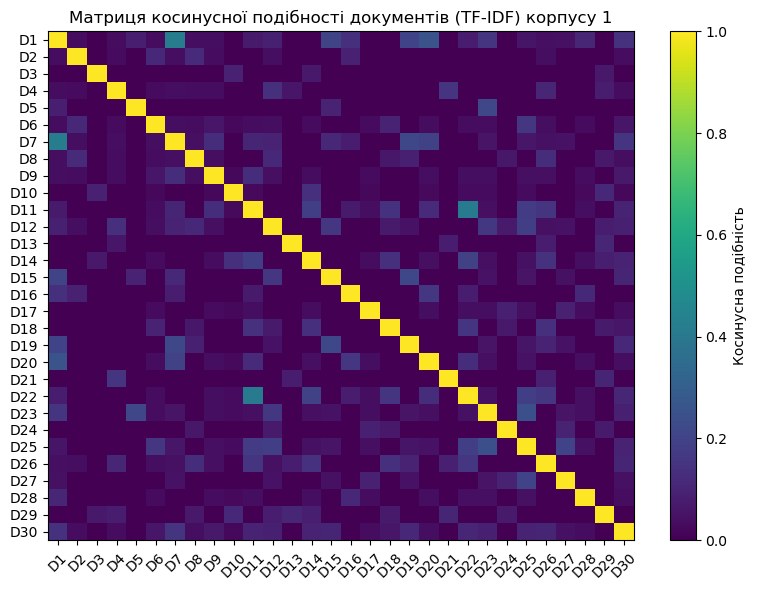

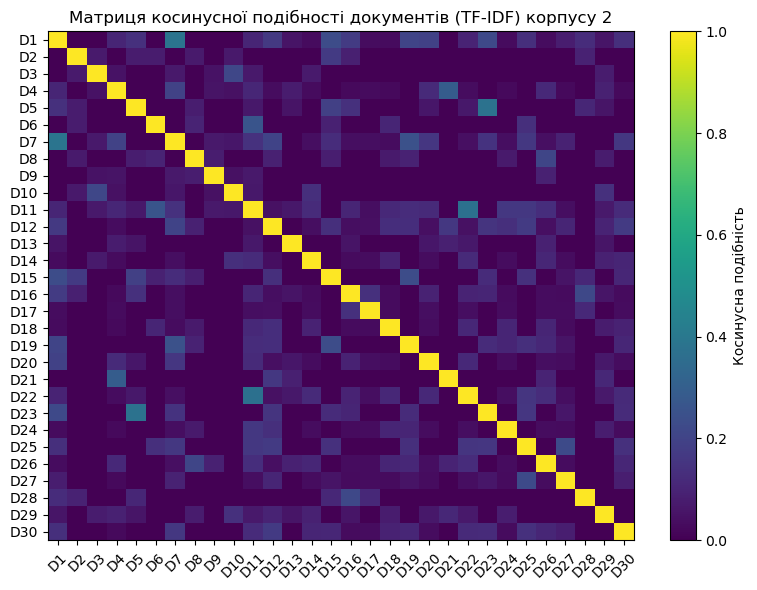

In [71]:
cosine_tfidf_1 = cosine_similarity(X_tfidf_1)

cosine_tfidf_df_1 = pd.DataFrame(
    cosine_tfidf_1,
    index=analysis_df_1["doc_id"],
    columns=analysis_df_1["doc_id"]
)

plt.figure(figsize=(8, 6))
plt.imshow(cosine_tfidf_df_1.values, aspect="auto")
plt.colorbar(label="Косинусна подібність")
plt.xticks(range(len(cosine_tfidf_df_1.columns)), cosine_tfidf_df_1.columns, rotation=45)
plt.yticks(range(len(cosine_tfidf_df_1.index)), cosine_tfidf_df_1.index)
plt.title("Матриця косинусної подібності документів (TF-IDF) корпусу 1")
plt.tight_layout()
plt.show()

cosine_tfidf_2 = cosine_similarity(X_tfidf_2)

cosine_tfidf_df_2 = pd.DataFrame(
    cosine_tfidf_2,
    index=analysis_df_2["doc_id"],
    columns=analysis_df_2["doc_id"]
)

plt.figure(figsize=(8, 6))
plt.imshow(cosine_tfidf_df_2.values, aspect="auto")
plt.colorbar(label="Косинусна подібність")
plt.xticks(range(len(cosine_tfidf_df_2.columns)), cosine_tfidf_df_2.columns, rotation=45)
plt.yticks(range(len(cosine_tfidf_df_2.index)), cosine_tfidf_df_2.index)
plt.title("Матриця косинусної подібності документів (TF-IDF) корпусу 2")
plt.tight_layout()
plt.show()

## 14. Пошук найбільш схожих пар документів

Із матриці подібності корисно витягнути *пари різних документів*, які мають найбільшу близькість.  
Це типова операція для задач:

- пошуку дублетів;
- рекомендацій схожого контенту;
- попереднього групування документів.


In [73]:
pairs_1 = []
doc_ids_1 = list(analysis_df_1["doc_id"])

for i in range(len(doc_ids_1)):
    for j in range(i + 1, len(doc_ids_1)):
        pairs_1.append({
            "doc_1": doc_ids_1[i],
            "doc_2": doc_ids_1[j],
            "cosine_tfidf": cosine_tfidf_df_1.loc[doc_ids_1[i], doc_ids_1[j]]
        })

pairs_df_1 = pd.DataFrame(pairs_1).sort_values("cosine_tfidf", ascending=False).reset_index(drop=True)
display(pairs_df_1.head(10).round(3))

pairs_2 = []
doc_ids_2 = list(analysis_df_2["doc_id"])

for i in range(len(doc_ids_2)):
    for j in range(i + 1, len(doc_ids_2)):
        pairs_2.append({
            "doc_1": doc_ids_2[i],
            "doc_2": doc_ids_2[j],
            "cosine_tfidf": cosine_tfidf_df_2.loc[doc_ids_2[i], doc_ids_2[j]]
        })

pairs_df = pd.DataFrame(pairs_2).sort_values("cosine_tfidf", ascending=False).reset_index(drop=True)
display(pairs_df.head(10).round(3))


,doc_1,doc_2,cosine_tfidf
0,D1,D7,0.419
1,D11,D22,0.415
2,D1,D20,0.254
3,D23,D25,0.245
4,D7,D19,0.218
5,D15,D19,0.217
6,D5,D23,0.213
7,D1,D15,0.205
8,D25,D27,0.203
9,D1,D19,0.202


,doc_1,doc_2,cosine_tfidf
0,D1,D7,0.384
1,D5,D23,0.378
2,D11,D22,0.369
3,D4,D21,0.293
4,D6,D11,0.259
5,D7,D19,0.248
6,D15,D19,0.234
7,D1,D15,0.231
8,D25,D27,0.225
9,D1,D23,0.221


## Висновки

У ході виконання лабораторної роботи було опрацьовано основні методи того, як можна векторизувати корпуси та як можна проаназувати корпуси і їх окремі документи. Було обрано тексти на тему аналізу текстів та машинного навчання. Загалом було обрано 20 текстів в додачу до базового корпусу із 10 текстів.
Було побудовано два різні варіанти корпусу: зі стоп-словами та без стоп-слів. Словник без стоп-слів також був опрацьований стемінгом, тому слова втратили своє закінчення для об'єднання однакових за сенсом слів як одне.
Очевидно, що другий корпус буде мати менший словник за другий через виконання фільтрації та стемінгу.
Було побудовано модель Bag of Words, що чітко показав нам тему другого корпусу ("текст", "навчання", "аналіз", "майнінг"), та не дуже гарно спрацював для першого корпусу, що має багато слів, що не несуть сенсу окремо ("та", "для").
Було сформовано матрицю документ-термін, розмірність якої мерше у другого корпусу, а також і розрідженість.
Для корпусів було обчислено IF-IDF-подання. Цікаво, що найважливіши слова за IF-IDF є однаковими що і у першого і у другого корпусу.
Також було знайдено найбіль подібні пари документів. Як видно по кольорам графіку, то очищений корпус має загалом більшу схожість документів між собою, ніж у першого.


## Контрольні питання

1. У чому полягає ідея моделі *Bag of Words*?
Модель ігнорує граматику та послідовність слів, фокусуючись лише на частоті їх появи в документі. Кожен документ стає вектором, де розмірність дорівнює кількості унікальних слів у всьому корпусі.
2. Що таке матриця *документ–термін*?
Матриця "документ–термін" — це структуроване представлення всього корпусу, де рядки відповідають документам, а стовпці — унікальним словам (термінам). На відміну від простої таблиці частот для одного тексту, вона дозволяє порівнювати документи між собою в єдиному багатовимірному просторі ознак.
3. Чому порядок слів у моделі BoW втрачається?
Тому що модель фіксує лише сам факт наявності слова та кількість його входжень у документ.
4. Що показує величина TF?
Вона обчислюється як відношення кількості входжень слова до загальної кількості слів у цьому документі.
5. Що показує величина IDF?
IDF вимірює важливість слова в масштабах усього корпусу.
6. Для чого використовується *TF-IDF*?
Для створення вагових коефіцієнтів, які дозволяють автоматично виділяти ключові слова. Вона допомагає моделі ігнорувати загальновживані слова (сполучники, прикметники загального змісту) і фокусуватися на термінах, що найкраще описують унікальну тематику тексту.
7. Чому дуже частотні слова часто мають меншу розрізнювальну здатність?
Якщо слово зустрічається майже в кожному документі, воно не дає інформації про те, чим один документ відрізняється від іншого.
8. Що означає косинусна подібність між двома документами?
Це міра подібності, яка обчислює косинус кута між векторами документів. Вона показує, наскільки близькі тексти за своїм лексичним складом.
9. Чому матриці текстових ознак зазвичай є розрідженими?
Оскільки загальний словник корпусу може налічувати тисячі слів, а кожен окремий документ складається лише з кількох десятків чи сотень унікальних слів.
10. Які переваги та обмеження має модель *Bag of Words*?
Переваги включають простоту реалізації, ефективність для класифікації простих тематик. Обмеженням є повна втрата контексту та порядку слів.
11. Чим TF-IDF зазвичай кращий за прості абсолютні частоти?
TF-IDF нівелює вплив "шумових" слів, які часто зустрічаються випадково, і автоматично масштабує значення так, щоб довгі та короткі документи можна було порівнювати коректно.
12. Для яких прикладних задач корисне векторне подання тексту?
Для кластеризації за категоріями, для пошуку, для порівняння документів на схожість.
